# Low-Risk Anomaly 프로젝트 - 데이터 수집 (통합)

## 전체 파이프라인
1. **유니버스 구성**: S&P500 역사적 구성 종목 (생존편향 완화)
2. **가격 데이터**: yfinance (일별 OHLCV)
3. **피처 계산**: vol, beta, mcap, 월별 수익률
4. **월별 패널 (기본)**: monthly_panel.csv - 99_baseline.ipynb용
5. **ML 보조 데이터**: 섹터 ETF / Fama-French / 매크로
6. **ML 확장 피처 함수**: 모멘텀, 기술적 지표, 리스크 조정
7. **월별 패널 (ML)**: monthly_panel_ml.csv - 05_ML_Q_predict.ipynb용

## 기본 패널 수집 변수 (monthly_panel.csv)
| 변수 | 설명 | 용도 |
|------|------|------|
| vol_21d | 21일 실현변동성 | P 분류 기준 (99_baseline) |
| vol_60d | 60일 실현변동성 | EDA |
| vol_252d | 252일 실현변동성 | 저위험 분류 기준 |
| beta_252d | 252일 CAPM 베타 (vs SPY) | 저위험 분류 기준 |
| log_mcap | 로그 시가총액 | P 행렬 가중치 (BL) |
| gics_sector | GICS 섹터 | 섹터 분석 |
| ret_1m | 월별 수익률 | 성과 검증 |
| fwd_ret_1m | 다음달 수익률 | 성과 검증 |

## ML 패널 추가 피처 (monthly_panel_ml.csv)
| 피처 군 | 변수 | 설명 |
|------|------|------|
| 모멘텀 | mom_1w, mom_1m, mom_3m, mom_6m, mom_12m | 단기~장기 수익률 |
| 모멘텀 | mom_12m_skip_1m, chmom | 12m skip 1m, 6m 모멘텀 변화 |
| 변동성 | vol_21d, vol_60d, vol_252d | 단기~장기 실현변동성 |
| 변동성 | idiovol_21d, ivol_63d | 이디오 변동성 (FF rf 기준) |
| 기술적 | rsi_14, bb_pct | RSI, 볼린저 밴드 위치 |
| 기술적 | high52w_ratio, low52w_ratio | 52주 고/저가 대비 |
| 기술적 | ma_gap_20_60, maxret_21d | MA 갭, 최대 일수익 |
| 기술적 | autocorr_21d | 1일 자기상관 (mean reversion 여부) |
| 유동성 | vol_surge, dollar_vol_21d | 거래량 급증, 달러 거래대금 |
| 유동성 | amihud_21d | Amihud 비유동성 지표 |
| 리스크 조정 | sharpe_21d, sharpe_63d | 샤프 비율 |
| 리스크 조정 | sortino_63d, ir_63d | 소르티노, 정보비율 |
| 리스크 조정 | skew_63d, kurt_63d, mdd_252d | 비대칭, 첨도, 최대낙폭 |
| 섹터 | indmom | 섹터 ETF 12개월 수익률 |
| 섹터 | is_Energy, is_Financials ... | GICS 11개 섹터 원핫 |
| 매크로 | vix, t10y2y, dxy | 변동성, 장단기 금리차, 달러 |
| 매크로 | gold, wti_crude, copper, silver | 원자재 |
| 매크로 | skew_idx, icsa, sahm, cpi, unrate | SKEW, FRED 시리즈 |
| FF 팩터 | ff_mkt_rf, ff_smb, ff_hml | Fama-French 5팩터 + MOM |

## 설계 결정사항
- **생존편향**: Wikipedia S&P500 변경 히스토리 역방향 재구성
- **중복 티커**: GOOGL/GOOG -> GOOGL, BRK.A/BRK.B -> BRK.B
- **기본/ML 패널 분리**: monthly_panel.csv는 BL 백테스트용, monthly_panel_ml.csv는 ML Q 예측용
- **Unknown 섹터**: 유니버스에 포함 (indmom NaN 처리)


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import pickle
import time
import warnings
import platform
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# PRICE_START : 2004-01-01 → rolling(252) 워밍업 + ret_1m 첫 행 확보
# PRICE_END   : 2026-03-31 → 2025-12 fwd_ret_1m 계산을 위해 1분기 더 수집
# PANEL_START : 2005-01-01 → 금융위기(2008) 포함을 위해 1년 앞당김
# PANEL_END   : 2025-12-31 → 실제 분석 패널 종료
PRICE_START = '2004-01-01'
PRICE_END   = '2026-03-31'
PANEL_START = '2010-01-01'
PANEL_END   = '2024-12-31'

print(f'데이터 경로: {DATA_DIR}')
print(f'가격 수집 기간: {PRICE_START} ~ {PRICE_END}')
print(f'패널 기간:     {PANEL_START} ~ {PANEL_END}')
print(f'→ TRAIN_WINDOW=36개월 시 2008-01부터 예측 가능 (금융위기 포함)')

데이터 경로: c:\workspace\camp\project\finance_project\서윤범\low_risk\data
가격 수집 기간: 2004-01-01 ~ 2026-03-31
패널 기간:     2010-01-01 ~ 2024-12-31
→ TRAIN_WINDOW=36개월 시 2008-01부터 예측 가능 (금융위기 포함)


# 1. S&P500 유니버스 구성 (생존편향 완화)

## 핵심 아이디어
- Wikipedia S&P500 현재 구성 + 변경 히스토리 → **역방향 재구성**
- 매월 "그 시점에 실제로 편입되어 있던 종목"만 패널에 포함
- 상장폐지/편출된 종목도 포함 → 생존편향 완화

## GOOGL/GOOG 중복 문제
- Alphabet은 GOOGL(Class A)과 GOOG(Class C) 두 종목이 모두 S&P500에 편입
- 같은 회사를 두 번 포함하면 공분산 행렬 추정에 왜곡 발생
- **해결**: GOOGL만 사용, GOOG 제거
- 같은 이유로 BRK.A → BRK.B만 사용

In [2]:
import requests
from bs4 import BeautifulSoup

DUPLICATE_DROP = {'GOOG', 'BRK.A'}

URL     = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot/1.0)'}

def fetch_sp500_tables():
    """Wikipedia S&P500 페이지에서 wikitable 2개 반환"""
    resp = requests.get(URL, headers=HEADERS, timeout=30)
    resp.raise_for_status()
    soup   = BeautifulSoup(resp.text, 'html.parser')
    tables = soup.find_all('table', {'class': 'wikitable'})
    if len(tables) < 2:
        raise ValueError(f"테이블 {len(tables)}개만 발견 (최소 2개 필요) — Wikipedia 구조 변경 가능성")
    return tables

def parse_current_sp500(table) -> pd.DataFrame:
    df = pd.read_html(str(table))[0]
    df.columns = [c.lower().replace(' ', '_') for c in df.columns]
    col_map = {}
    for c in df.columns:
        if 'symbol' in c or 'ticker' in c: col_map[c] = 'ticker'
        if 'gics_sector' in c or 'sector' in c: col_map[c] = 'gics_sector'
    df = df.rename(columns=col_map)
    df['ticker'] = df['ticker'].str.replace('.', '-', regex=False).str.strip()
    return df[['ticker', 'gics_sector']].drop_duplicates('ticker')

def parse_changes(table) -> pd.DataFrame:
    df = pd.read_html(str(table))[0]
    df.columns = ['_'.join(str(c).lower().split()) for c in df.columns]

    date_col    = next((c for c in df.columns if 'date'  in c), None)
    added_col   = next((c for c in df.columns if 'added'  in c and 'ticker' in c), None)
    removed_col = next((c for c in df.columns if 'remov'  in c and 'ticker' in c), None)

    if date_col is None:
        return pd.DataFrame(columns=['date', 'added', 'removed'])

    df = df[[date_col,
             added_col   if added_col   else df.columns[0],
             removed_col if removed_col else df.columns[0]]].copy()
    df.columns = ['date', 'added', 'removed']
    df['date']    = pd.to_datetime(df['date'], errors='coerce')
    df            = df.dropna(subset=['date'])
    df['added']   = df['added'].astype(str).str.replace('.', '-', regex=False).str.strip()
    df['removed'] = df['removed'].astype(str).str.replace('.', '-', regex=False).str.strip()
    return df

def build_monthly_membership(df_current, df_changes, start, end) -> dict:
    """
    역방향 재구성: 현재 구성에서 시작해 변경 이벤트를 거꾸로 적용
    → 각 월말 시점의 S&P500 구성 종목 반환
    """
    monthly_dates = pd.date_range(start, end, freq='ME')
    current_set   = set(df_current['ticker'].tolist())
    membership    = {}

    for target in sorted(monthly_dates, reverse=True):
        for _, row in df_changes[df_changes['date'] > target].iterrows():
            added   = str(row['added']).strip()
            removed = str(row['removed']).strip()
            if added   and added   != 'nan': current_set.discard(added)
            if removed and removed != 'nan': current_set.add(removed)
        membership[target] = frozenset(current_set)

    return membership

# ── Wikipedia 수집 ──────────────────────────────────────
MEMBERSHIP_PATH = DATA_DIR / 'sp500_membership.pkl'

if MEMBERSHIP_PATH.exists():
    with open(MEMBERSHIP_PATH, 'rb') as f:
        sp500_membership = pickle.load(f)
    print(f"멤버십 히스토리 로드: {len(sp500_membership)}개 월")
else:
    print("Wikipedia에서 S&P500 데이터 수집 중...")
    tables     = fetch_sp500_tables()
    df_current = parse_current_sp500(tables[0])
    df_changes = parse_changes(tables[1])
    print(f"  현재 구성: {len(df_current)}종목 / 변경 이벤트: {len(df_changes)}건")

    sp500_membership = build_monthly_membership(df_current, df_changes, PRICE_START, PRICE_END)
    with open(MEMBERSHIP_PATH, 'wb') as f:
        pickle.dump(sp500_membership, f)
    print(f"  멤버십 생성 완료: {len(sp500_membership)}개 월")

멤버십 히스토리 로드: 267개 월


In [3]:
# ── 전체 유니버스 (역사적으로 한 번이라도 편입된 종목) ────────
UNIVERSE_PATH = DATA_DIR / 'universe.csv'

if UNIVERSE_PATH.exists():
    df_universe = pd.read_csv(UNIVERSE_PATH)
    print(f"유니버스 로드: {len(df_universe)}종목")
else:
    # 현재 구성 재수집 (섹터 매핑용)
    tables     = fetch_sp500_tables()
    df_current = parse_current_sp500(tables[0])
    sector_map = dict(zip(df_current['ticker'], df_current['gics_sector']))

    # 모든 월의 멤버 합집합
    all_tickers = set()
    for members in sp500_membership.values():
        all_tickers.update(members)
    
    # GOOGL/GOOG, BRK.A/BRK.B 중복 제거
    all_tickers -= DUPLICATE_DROP
    print(f"중복 제거 후 유니버스: {len(all_tickers)}종목")
    print(f"  제거된 티커: {DUPLICATE_DROP}")

    # 현재 구성에 없는 역사적 종목 → yfinance로 섹터 보완
    need_sector = all_tickers - set(sector_map.keys())
    print(f"  섹터 미확인 종목 {len(need_sector)}개 → yfinance 조회 중...")
    
    for i, t in enumerate(sorted(need_sector)):
        try:
            info = yf.Ticker(t).info
            sec  = info.get('sector', 'Unknown')
            sector_map[t] = sec
        except:
            sector_map[t] = 'Unknown'
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(need_sector)} 완료")
        time.sleep(0.1)

    df_universe = pd.DataFrame([
        {'ticker': t, 'gics_sector': sector_map.get(t, 'Unknown')}
        for t in sorted(all_tickers)
    ])
    df_universe.to_csv(UNIVERSE_PATH, index=False)
    print(f"\n유니버스 저장: {len(df_universe)}종목")

# Unknown 섹터 현황 확인
n_unknown = (df_universe['gics_sector'] == 'Unknown').sum()
print(f"\n섹터 분포:")
print(df_universe['gics_sector'].value_counts().to_string())
print(f"\n⚠ Unknown 섹터: {n_unknown}개 — 유니버스에는 포함 (indmom 미사용)")

유니버스 로드: 833종목

섹터 분포:
gics_sector
Unknown                   205
Industrials                94
Financials                 76
Information Technology     73
Health Care                58
Consumer Discretionary     48
Real Estate                36
Energy                     35
Consumer Staples           35
Consumer Cyclical          35
Utilities                  32
Communication Services     29
Materials                  26
Financial Services         17
Healthcare                 15
Technology                  9
Basic Materials             6
Consumer Defensive          4

⚠ Unknown 섹터: 205개 — 유니버스에는 포함 (indmom 미사용)


In [4]:
# ── 발행주식수 시계열 수집 (시가총액 계산용) ────────────────
SHARES_PATH = DATA_DIR / 'shares_outstanding.pkl'

if SHARES_PATH.exists():
    with open(SHARES_PATH, 'rb') as f:
        shares_map = pickle.load(f)
    print(f"발행주식수 로드: {len(shares_map)}종목")
else:
    tickers_all = df_universe['ticker'].tolist()
    shares_map  = {}
    print(f"발행주식수 수집 시작: {len(tickers_all)}종목")

    for i, t in enumerate(tickers_all):
        try:
            ts = yf.Ticker(t).get_shares_full(start=PRICE_START)
            if ts is not None and len(ts) > 0:
                shares_map[t] = ts
        except Exception:
            pass
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(tickers_all)} 완료 (수집 성공: {len(shares_map)}개)")
        time.sleep(0.05)

    with open(SHARES_PATH, 'wb') as f:
        pickle.dump(shares_map, f)
    print(f"\n저장 완료: {len(shares_map)}종목 / {len(tickers_all)}종목")

발행주식수 로드: 782종목


# 2. 가격 데이터 수집 (yfinance)

SPY(시장 벤치마크)와 무위험수익률(^IRX: 13주 T-bill)도 함께 수집합니다.

In [5]:
PRICES_PATH = DATA_DIR / 'prices_raw.pkl'
tickers     = df_universe['ticker'].tolist()

if PRICES_PATH.exists():
    prices_raw = pd.read_pickle(PRICES_PATH)
    print(f"가격 데이터 로드: {prices_raw.shape}")
else:
    all_symbols = ['SPY', '^IRX'] + tickers
    print(f"총 {len(all_symbols)}개 티커 다운로드 시작...")

    BATCH = 200
    dfs   = []
    for i in range(0, len(all_symbols), BATCH):
        batch = all_symbols[i:i+BATCH]
        print(f"  배치 {i//BATCH+1}: {batch[0]} ~ {batch[-1]} ({len(batch)}개)")
        df = yf.download(
            batch,
            start=PRICE_START,
            end=PRICE_END,
            auto_adjust=True,
            progress=False
        )
        dfs.append(df)
        time.sleep(1)

    prices_raw = pd.concat(dfs, axis=1)
    prices_raw = prices_raw.loc[:, ~prices_raw.columns.duplicated()]
    prices_raw.to_pickle(PRICES_PATH)
    print(f"\n저장 완료: {prices_raw.shape}")

# Close 가격 추출
if isinstance(prices_raw.columns, pd.MultiIndex):
    close = prices_raw['Close']
else:
    close = prices_raw[['Close']]

# 중복 날짜 제거 (yfinance 배치 다운로드 시 간헐적으로 발생)
n_dup = close.index.duplicated().sum()
if n_dup > 0:
    print(f"중복 날짜 {n_dup}개 제거")
    close = close[~close.index.duplicated(keep='last')]

print(f"\nClose 가격: {close.shape[0]}일 × {close.shape[1]}종목")
print(f"결측치 비율: {close.isna().mean().mean():.1%}")

가격 데이터 로드: (5595, 4339)

Close 가격: 5595일 × 835종목
결측치 비율: 31.6%


In [6]:
# ── 일별 가격 이상값 탐지 ────────────────────────────────
# 하루 사이 가격이 10배 이상 변하는 전환 시점 = yfinance 데이터 오류
# (예: TIE 2010-02: $11 → $20,700, ratio = 1780배)

JUMP_THRESHOLD = 10  # 하루 사이 10배 이상 변화

daily_ratio = close / close.shift(1)  # P_t / P_{t-1}
extreme_mask = (daily_ratio > JUMP_THRESHOLD) | (daily_ratio < 1 / JUMP_THRESHOLD)

# 티커별 이상값 발생 일수
bad_days_per_ticker = extreme_mask.sum()
affected = bad_days_per_ticker[bad_days_per_ticker > 0].sort_values(ascending=False)

print(f"=== 일별 가격 이상값 탐지 (기준: {JUMP_THRESHOLD}배 이상 변화) ===")
print(f"이상값 발생 티커: {len(affected)}개 / {close.shape[1]}개")
print(f"이상값 총 일수:   {int(affected.sum())}일")
print(f"\n[이상값 발생 티커 목록]")
print(affected.to_string())

=== 일별 가격 이상값 탐지 (기준: 10배 이상 변화) ===
이상값 발생 티커: 10개 / 835개
이상값 총 일수:   1106일

[이상값 발생 티커 목록]
Ticker
CBE     656
TIE     197
CFC     120
MEE      85
BMC      24
^IRX     10
CPWR      6
PTV       5
RSH       2
POM       1


In [7]:

# ── 오염 티커 제거 후 prices_raw.pkl 재저장 ──────────────────
# 기준 A (자동): 하루 사이 10배 이상 가격 변화
# 기준 B (자동): 60일 이상 연속 0 log_return (티커 혼재)

# --- A. 극단 수익률 ---
drop_A = set(affected.drop('^IRX', errors='ignore').index)

# --- B. 연속 0 log_return ---
CONSEC_THRESH = 60

def _max_consec_zero(s):
    s = s.dropna()
    max_c, cur = 0, 0
    for v in (s == 0):
        cur = cur + 1 if v else 0
        max_c = max(max_c, cur)
    return max_c

log_ret_tmp  = np.log(close / close.shift(1))
consec_zeros = {t: _max_consec_zero(log_ret_tmp[t]) for t in close.columns}
drop_B       = {t for t, v in consec_zeros.items() if v >= CONSEC_THRESH}

drop_tickers = sorted((drop_A | drop_B) & set(close.columns))

# --- close 정제 ---
close = close.drop(columns=drop_tickers)

# --- prices_raw MultiIndex 컬럼에서 해당 티커 제거 후 재저장 ---
if isinstance(prices_raw.columns, pd.MultiIndex):
    keep_mask    = ~prices_raw.columns.get_level_values(1).isin(drop_tickers)
    prices_raw   = prices_raw.loc[:, keep_mask]
    volume_df    = prices_raw['Volume'].copy() if 'Volume' in prices_raw.columns.get_level_values(0) else pd.DataFrame()
    high_df      = prices_raw['High'].copy()   if 'High'   in prices_raw.columns.get_level_values(0) else pd.DataFrame()
    low_df       = prices_raw['Low'].copy()    if 'Low'    in prices_raw.columns.get_level_values(0) else pd.DataFrame()
    volume_df    = volume_df[~volume_df.index.duplicated(keep='last')] if not volume_df.empty else volume_df
    high_df      = high_df[~high_df.index.duplicated(keep='last')]     if not high_df.empty   else high_df
    low_df       = low_df[~low_df.index.duplicated(keep='last')]       if not low_df.empty    else low_df
else:
    volume_df = high_df = low_df = pd.DataFrame()

prices_raw.to_pickle(PRICES_PATH)

print(f"=== 오염 티커 제거 완료 ===")
print(f"  A (극단 수익률 10배): {sorted(drop_A)}")
print(f"  B (연속 0, {CONSEC_THRESH}일+):  {sorted(drop_B)}")
print(f"  총 제거: {len(drop_tickers)}개 → {drop_tickers}")
print(f"  close shape    : {close.shape}")
print(f"  prices_raw shape: {prices_raw.shape}")
print(f"  prices_raw.pkl 재저장 완료: {PRICES_PATH}")


=== 오염 티커 제거 완료 ===
  A (극단 수익률 10배): ['BMC', 'CBE', 'CFC', 'CPWR', 'MEE', 'POM', 'PTV', 'RSH', 'TIE']
  B (연속 0, 60일+):  ['AMCR', 'BMC', 'CFC', 'CPWR', 'GLK', 'HOT', 'MEE', 'PTV', 'RSH', 'SW']
  총 제거: 13개 → ['AMCR', 'BMC', 'CBE', 'CFC', 'CPWR', 'GLK', 'HOT', 'MEE', 'POM', 'PTV', 'RSH', 'SW', 'TIE']
  close shape    : (5595, 822)
  prices_raw shape: (5595, 4274)
  prices_raw.pkl 재저장 완료: c:\workspace\camp\project\finance_project\서윤범\low_risk\data\prices_raw.pkl


In [8]:
# Adj Close, Close, High, Low, Open, Volume
print(prices_raw.columns.get_level_values(0).unique())

# 전체 NA. 추후 제거
print(prices_raw['Adj Close'].isna().sum())

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Ticker
ABK     5595
ABMD    5595
ACAS    5595
ACE     5595
ADS     5595
        ... 
XEC     5595
XL      5595
XLNX    5595
XTO     5595
YHOO    5595
Length: 164, dtype: int64


In [9]:
# Close
# 가격 데이터 전체 NA 데이터는 추후 제거
sum(prices_raw['Close'].isna().all())

164

# 3. 피처 계산

## 계산 로직 요약
- **수익률**: log return 사용 (덧셈 가능, 정규분포에 가까움)
- **변동성**: rolling std of log return × √252 (연환산)
- **베타**: cov(stock, SPY) / var(SPY), rolling 252일
- **시가총액**: Close × Shares Outstanding — 없으면 Close로 대체 (순위 근사치)
- **무위험수익률**: ^IRX (13주 T-bill, 연율) → 일별 변환

## Look-ahead bias 방지
- 모든 rolling 계산은 과거 데이터만 사용 (forward-looking 없음)
- 타겟 변수 `fwd_ret_1m`은 shift(-1)로 미래 수익률 참조 (타겟 변수 전용)

<Axes: xlabel='SPY', ylabel='Count'>

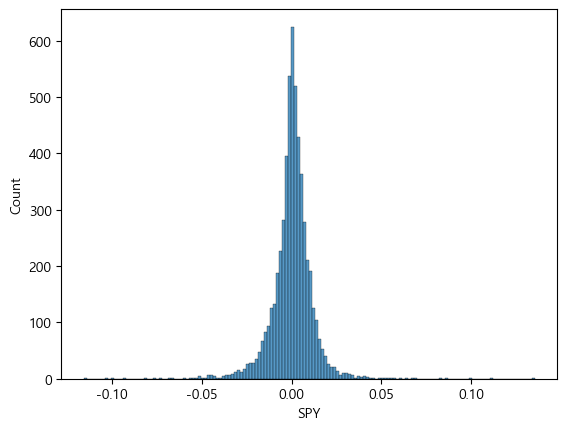

In [11]:
ANN = np.sqrt(252)

# SPY 일별 수익률 (베타 계산용)
spy_close = close['SPY']
spy_lr = np.log(spy_close / spy_close.shift(1))

sns.histplot(spy_lr)

In [12]:
ANN = np.sqrt(252)

spy_close = close['SPY']
spy_lr    = np.log(spy_close / spy_close.shift(1))

rf_annual = close['^IRX'] / 100
rf_daily  = (1 + rf_annual) ** (1/252) - 1

def compute_features(ticker: str, ac: pd.Series) -> pd.DataFrame:
    ac = ac[~ac.index.duplicated(keep='last')]

    df = pd.DataFrame(index=ac.index)

    lr  = np.log(ac / ac.shift(1))
    exc = lr - rf_daily.reindex(ac.index)
    mkt = spy_lr.reindex(ac.index)

    df['vol_21d']  = lr.rolling(21).std() * ANN   # 1개월 거래일 기준 (예측 타겟)
    df['vol_60d']  = lr.rolling(60).std() * ANN
    df['vol_252d'] = lr.rolling(252).std() * ANN

    cov_em          = exc.rolling(252).cov(mkt)
    var_m           = mkt.rolling(252).var()
    df['beta_252d'] = cov_em / var_m

    df['close'] = ac

    if ticker in shares_map:
        shares_ts = shares_map[ticker]
        shares_ts = shares_ts[~shares_ts.index.duplicated(keep='last')]
        if shares_ts.index.tz is not None:
            shares_ts.index = shares_ts.index.tz_localize(None)
        shares_ts = shares_ts.reindex(ac.index).ffill().bfill()
        df['log_mcap'] = np.log((ac * shares_ts).clip(lower=1))
    else:
        df['log_mcap'] = np.log(ac.clip(lower=1e-6))

    r1  = 1 + ac.pct_change()
    df['fwd_ret_1m'] = r1.shift(-1).rolling(21).apply(np.prod, raw=True).shift(-20) - 1

    df['ticker'] = ticker
    return df

print("피처 계산 함수 정의 완료")
print(f"발행주식수 보유 종목: {len(shares_map)}개 / {len(df_universe)}개")
print(f"추가된 피처: vol_21d (21일 롤링, 월별 실현변동성 기준)")

피처 계산 함수 정의 완료
발행주식수 보유 종목: 782개 / 833개
추가된 피처: vol_21d (21일 롤링, 월별 실현변동성 기준)


# 4. 월별 패널 구성

각 종목의 일별 피처를 월말(Month-End)로 리샘플링하고,  
**해당 월에 실제로 S&P500에 편입되어 있던 종목만** 패널에 포함합니다.  
(생존편향 완화의 핵심 단계)

In [13]:
PANEL_PATH = DATA_DIR / 'monthly_panel.csv'

if PANEL_PATH.exists():
    monthly_df = pd.read_csv(PANEL_PATH, parse_dates=['date'])
    monthly_df = monthly_df.set_index(['date', 'ticker'])
    print(f"패널 로드: {monthly_df.shape}")
else:
    sector_map       = dict(zip(df_universe['ticker'], df_universe['gics_sector']))
    membership_dates = sorted(sp500_membership.keys())

    def get_members_at(date: pd.Timestamp) -> frozenset:
        idx = pd.Series(membership_dates).searchsorted(date, side='right') - 1
        if idx < 0:
            return frozenset()
        return sp500_membership[membership_dates[idx]]

    monthly_panels = []
    valid_tickers  = [t for t in tickers if t in close.columns]
    print(f"피처 계산 시작: {len(valid_tickers)}종목")

    for i, ticker in enumerate(valid_tickers):
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(valid_tickers)} 완료")

        ac = close[ticker].dropna()
        if len(ac) < 252:
            continue

        df = compute_features(ticker, ac)

        df_m = df.resample('ME').last()
        df_m['ticker']      = ticker
        df_m['gics_sector'] = sector_map.get(ticker, 'Unknown')

        df_m = df_m[(df_m.index >= PANEL_START) & (df_m.index <= PANEL_END)]
        monthly_panels.append(df_m)

    monthly_df = pd.concat(monthly_panels)
    monthly_df.index.name = 'date'
    monthly_df = monthly_df.reset_index().set_index(['date', 'ticker'])
    monthly_df = monthly_df.sort_index()

    # ── 생존편향 필터 ────────────────────────────────────
    print("생존편향 필터 적용 중...")
    mask = [(ticker in get_members_at(date))
            for (date, ticker), _ in monthly_df.iterrows()]
    monthly_df = monthly_df[mask]
    print(f"필터 후: {monthly_df.shape[0]}행 ({monthly_df.index.get_level_values('ticker').nunique()}종목)")

    # ── SPY 월별 수익률 ───────────────────────────────────
    spy_monthly = spy_close.resample('ME').last().pct_change().rename('spy_ret')
    monthly_df  = monthly_df.join(spy_monthly, on='date')

    # ── RF 월별 환산 ──────────────────────────────────────
    rf_monthly = rf_daily.resample('ME').apply(lambda x: (1+x).prod()-1).rename('rf_1m')
    monthly_df = monthly_df.join(rf_monthly, on='date')

    # ── ret_1m: 전체 가격 히스토리로 계산 ────────────────
    monthly_close_full = close[valid_tickers].resample('ME').last()
    monthly_ret        = monthly_close_full.pct_change()
    monthly_ret        = monthly_ret.stack(future_stack=True).rename('ret_1m')
    monthly_ret.index.names = ['date', 'ticker']  # yfinance 컬럼명과 monthly_df 인덱스명 통일
    monthly_df = monthly_df.join(monthly_ret)

    monthly_df.to_csv(PANEL_PATH)
    print(f"\n패널 저장: {PANEL_PATH}")

print(f"\n최종 패널: {monthly_df.shape}")
print(f"기간: {monthly_df.index.get_level_values('date').min().date()} ~ {monthly_df.index.get_level_values('date').max().date()}")
print(f"종목 수: {monthly_df.index.get_level_values('ticker').nunique()}")
print(f"\n컬럼:")
print(monthly_df.dtypes)

패널 로드: (108180, 11)

최종 패널: (108180, 11)
기간: 2004-01-31 ~ 2025-12-31
종목 수: 621

컬럼:
vol_21d        float64
vol_60d        float64
vol_252d       float64
beta_252d      float64
close          float64
log_mcap       float64
fwd_ret_1m     float64
gics_sector     object
spy_ret        float64
rf_1m          float64
ret_1m         float64
dtype: object


In [14]:
# ── 패널 기간 검증 ──────────────────────────────────────
actual_start = monthly_df.index.get_level_values('date').min()
actual_end   = monthly_df.index.get_level_values('date').max()

print(f"설정 PANEL_START : {PANEL_START}")
print(f"실제 패널 시작일 : {actual_start.date()}")
print(f"실제 패널 종료일 : {actual_end.date()}")

assert actual_start >= pd.Timestamp(PANEL_START), \
    f"패널 시작일({actual_start.date()})이 PANEL_START({PANEL_START})보다 이름!"
print("시작일 검증 OK")

설정 PANEL_START : 2004-01-01
실제 패널 시작일 : 2004-01-31
실제 패널 종료일 : 2025-12-31
시작일 검증 OK


# 5. 데이터 품질 확인

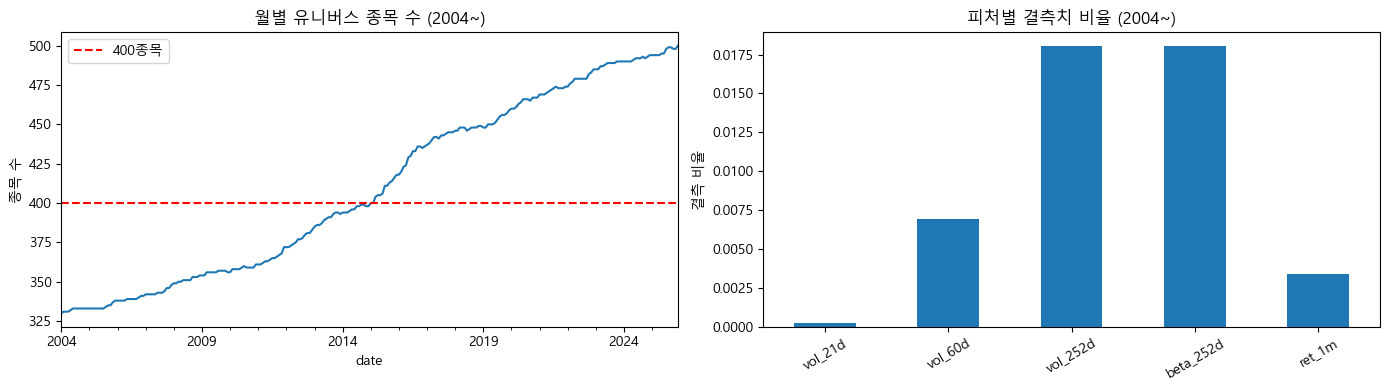

=== 2004년 이후 결측치 수 ===
vol_21d          28
vol_60d         748
vol_252d       1950
beta_252d      1950
close             0
log_mcap          0
fwd_ret_1m        3
gics_sector       0
spy_ret         330
rf_1m             0
ret_1m          369

=== 기초 통계 (2004~2026) ===
            ret_1m      vol_21d     vol_252d    beta_252d      spy_ret  \
count  107811.0000  108152.0000  106230.0000  106230.0000  107850.0000   
mean        0.0109       0.2886       0.3091       1.0080       0.0098   
std         0.0906       0.2053       0.1708       0.4127       0.0422   
min        -0.8435       0.0000       0.0905      -1.6580      -0.1652   
25%        -0.0365       0.1741       0.2066       0.7455      -0.0134   
50%         0.0114       0.2375       0.2654       0.9857       0.0151   
75%         0.0568       0.3334       0.3589       1.2418       0.0356   
max         2.4498       4.8805       2.8059       3.9243       0.1270   

             rf_1m  
count  108180.0000  
mean        0.0014  


In [15]:
import matplotlib.pyplot as plt

# 분석 기간 데이터만 사용 (PANEL_START 이후)
panel_dates = monthly_df.index.get_level_values('date')
df_plot = monthly_df[panel_dates >= PANEL_START]

# ── 1. 월별 종목 수 추이 ──────────────────────────────────
monthly_counts = df_plot.groupby(level='date').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_counts.plot(ax=axes[0], title=f'월별 유니버스 종목 수 ({PANEL_START[:4]}~)')
axes[0].axhline(400, color='r', linestyle='--', label='400종목')
axes[0].set_ylabel('종목 수')
axes[0].legend()

# ── 2. 결측치 비율 (PANEL_START 이후 기준) ───────────────
na_rate = df_plot[['vol_21d','vol_60d','vol_252d','beta_252d','ret_1m']].isna().mean()
na_rate.plot(kind='bar', ax=axes[1], title=f'피처별 결측치 비율 ({PANEL_START[:4]}~)')
axes[1].set_ylabel('결측 비율')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── 2-1. 결측치 수 (PANEL_START 이후) ────────────────────
print(f"=== {PANEL_START[:4]}년 이후 결측치 수 ===")
print(df_plot.isna().sum().to_string())

# ── 3. 기초 통계 (PANEL_START 이후 기준) ─────────────────
print(f"\n=== 기초 통계 ({PANEL_START[:4]}~{PRICE_END[:4]}) ===")
print(df_plot[['ret_1m','vol_21d','vol_252d','beta_252d','spy_ret','rf_1m']].describe().round(4))

# ── 4. 유니버스 → 패널 종목 수 흐름 ──────────────────────
tickers_in_panel = set(monthly_df.index.get_level_values('ticker'))
n_universe       = len(df_universe)
n_no_price       = sum(close[t].isna().all() for t in df_universe['ticker'] if t in close.columns)
n_short          = sum(1 for t in df_universe['ticker']
                       if t in close.columns and 0 < len(close[t].dropna()) < 252)
n_panel          = len(tickers_in_panel)

print(f"\n=== 유니버스 → 패널 종목 수 흐름 ===")
print(f"  유니버스 전체:       {n_universe}종목")
print(f"  가격 데이터 전무:   -{n_no_price}종목  (yfinance에 데이터 없음)")
print(f"  데이터 252일 미만:  -{n_short}종목  (상장기간 짧음)")
print(f"  최종 패널 종목 수:   {n_panel}종목")

# ── 5. Unknown 섹터 잔존 현황 ─────────────────────────────
unknown_tickers = set(df_universe.loc[df_universe['gics_sector'] == 'Unknown', 'ticker'])
n_unknown_total = len(unknown_tickers)
n_unknown_panel = len(unknown_tickers & tickers_in_panel)

print(f"\n=== Unknown 섹터 현황 ===")
print(f"  유니버스 내 Unknown:   {n_unknown_total}종목")
print(f"  패널에 잔존한 Unknown: {n_unknown_panel}종목  (가격 데이터 있어 포함)")
print(f"  필터링된 Unknown:      {n_unknown_total - n_unknown_panel}종목")

# ── 6. GOOGL/GOOG 중복 제거 확인 ─────────────────────────
print(f"\n=== 중복 제거 확인 ===")
print(f"  GOOG  포함: {'GOOG'  in tickers_in_panel}")
print(f"  GOOGL 포함: {'GOOGL' in tickers_in_panel}")
print(f"  BRK-A 포함: {'BRK-A' in tickers_in_panel}")
print(f"  BRK-B 포함: {'BRK-B' in tickers_in_panel}")

In [16]:
sizes = pd.Series({date: len(members) for date, members in sp500_membership.items()})
sizes = sizes.sort_index()
print("월별 S&P500 멤버십 크기:")
print(sizes.describe().round(0))
print(sizes.head(10))
print(sizes.tail(10))

월별 S&P500 멤버십 크기:
count    267.0
mean     508.0
std        4.0
min      503.0
25%      506.0
50%      507.0
75%      511.0
max      516.0
dtype: float64
2004-01-31    515
2004-02-29    515
2004-03-31    515
2004-04-30    515
2004-05-31    515
2004-06-30    515
2004-07-31    515
2004-08-31    515
2004-09-30    515
2004-10-31    515
dtype: int64
2025-06-30    503
2025-07-31    503
2025-08-31    503
2025-09-30    503
2025-10-31    503
2025-11-30    503
2025-12-31    503
2026-01-31    503
2026-02-28    503
2026-03-31    503
dtype: int64


In [17]:
nan_count = sum(prices_raw['Close'].isna().all())
print(f"all-NaN 티커: {nan_count}개")

all-NaN 티커: 164개


# 6. ML 보조 데이터 수집 (섹터 ETF / Fama-French / 매크로)

모두 캐시 파일이 존재하면 스킵합니다.

| 데이터 | 파일 | 용도 |
|---|---|---|
| 섹터 ETF | `sector_etf.pkl` | 섹터별 12개월 수익률 → indmom |
| FF5 일별 | `ff_factors_daily.csv` | rf_daily_ff, mkt_rf_daily (beta/idiovol 계산) |
| FF3 월별 | `ff3_monthly.csv` | rf_monthly_ff (fwd_excess_ret_1m 계산) |
| FF5 월별 | `ff5_monthly.csv` | 매크로 피처 (mkt_rf, smb, hml, rmw, cma, mom_factor) |
| 매크로 | `macro_daily.csv` | vix, t10y2y, dxy, gold 등 + FRED (icsa, sahm, cpi, unrate) |

In [ ]:
import io, zipfile, re

# ── 멤버십 헬퍼 (Section 1 캐시 재사용) ──────────────────────
import bisect
_membership_dates_ml = sorted(sp500_membership.keys())
def get_members_at(date):
    idx = bisect.bisect_right(_membership_dates_ml, date) - 1
    return sp500_membership[_membership_dates_ml[idx]] if idx >= 0 else frozenset()

# ── 섹터 ETF (indmom 계산용) ──────────────────────────────────
SECTOR_ETF_MAP = {
    'Energy': 'XLE', 'Materials': 'XLB', 'Industrials': 'XLI',
    'Consumer Discretionary': 'XLY', 'Consumer Staples': 'XLP',
    'Health Care': 'XLV', 'Financials': 'XLF', 'Information Technology': 'XLK',
    'Communication Services': 'XLC', 'Utilities': 'XLU', 'Real Estate': 'XLRE',
}
SECTOR_NORMALIZE = {
    'Consumer Cyclical': 'Consumer Discretionary', 'Consumer Defensive': 'Consumer Staples',
    'Healthcare': 'Health Care', 'Financial Services': 'Financials',
    'Technology': 'Information Technology', 'Basic Materials': 'Materials',
}
VALID_SECTORS = list(SECTOR_ETF_MAP.keys())

SECTOR_ETF_PATH = DATA_DIR / 'sector_etf.pkl'
if SECTOR_ETF_PATH.exists():
    indmom_by_sector = pickle.load(open(SECTOR_ETF_PATH, 'rb'))
    print(f'섹터 ETF 로드: {len(indmom_by_sector)}개 섹터')
else:
    print('섹터 ETF 다운로드 중...')
    etf_raw   = yf.download(list(SECTOR_ETF_MAP.values()), start=PRICE_START, end=PRICE_END,
                            auto_adjust=True, progress=False)
    etf_close = etf_raw['Close'] if isinstance(etf_raw.columns, pd.MultiIndex) else etf_raw
    indmom_by_sector = {}
    for sec, etf in SECTOR_ETF_MAP.items():
        if etf in etf_close.columns:
            r = etf_close[etf].pct_change()
            indmom_by_sector[sec] = (1 + r).rolling(252).apply(np.prod, raw=True) - 1
    pickle.dump(indmom_by_sector, open(SECTOR_ETF_PATH, 'wb'))
    print(f'섹터 ETF 저장: {len(indmom_by_sector)}개 섹터')

# ── Fama-French 팩터 ──────────────────────────────────────────
FF_DAILY_PATH   = DATA_DIR / 'ff_factors_daily.csv'
FF_MONTHLY_PATH = DATA_DIR / 'ff3_monthly.csv'
FF5M_PATH       = DATA_DIR / 'ff5_monthly.csv'

def _download_ff_zip(url, is_daily=True):
    r = requests.get(url, timeout=60); r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    pat   = r'^\s*\d{8}\s*,' if is_daily else r'^\s*\d{6}\s*,'
    start = next(i for i, ln in enumerate(lines) if re.match(pat, ln))
    end   = next((i for i in range(start, len(lines)) if not re.match(pat, lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    dc = df.columns[0]
    if is_daily:
        df[dc] = pd.to_datetime(df[dc].astype(int).astype(str), format='%Y%m%d')
    else:
        df[dc] = pd.to_datetime(df[dc].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    return df.rename(columns={dc: 'date'}).set_index('date').astype(float) / 100.0

if FF_DAILY_PATH.exists():
    df_ff = pd.read_csv(FF_DAILY_PATH, index_col='date', parse_dates=True)
    print(f'FF 일별 캐시: {df_ff.shape}')
else:
    print('FF5 + MOM 일별 다운로드 중...')
    df_ff5 = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip')
    df_ff5 = df_ff5.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','RMW':'rmw','CMA':'cma','RF':'rf'})
    df_mom = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip')
    df_mom = df_mom.rename(columns={df_mom.columns[0]: 'mom_factor'})
    df_ff  = df_ff5.join(df_mom[['mom_factor']], how='inner')
    df_ff  = df_ff[(df_ff.index >= pd.Timestamp(PRICE_START)) & (df_ff.index <= pd.Timestamp(PRICE_END))]
    df_ff.to_csv(FF_DAILY_PATH)
    print(f'FF 일별 저장: {df_ff.shape}')

if FF_MONTHLY_PATH.exists():
    ff3_m = pd.read_csv(FF_MONTHLY_PATH, index_col='date', parse_dates=True)
else:
    ff3_m = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip', is_daily=False)
    ff3_m = ff3_m.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','RF':'rf'})
    ff3_m.to_csv(FF_MONTHLY_PATH)

if FF5M_PATH.exists():
    ff5_m = pd.read_csv(FF5M_PATH, index_col='date', parse_dates=True)
else:
    ff5_m = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip', is_daily=False)
    ff5_m = ff5_m.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','RMW':'rmw','CMA':'cma','RF':'rf'})
    mom_m = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip', is_daily=False)
    ff5_m = ff5_m.join(mom_m.rename(columns={mom_m.columns[0]:'mom_factor'})[['mom_factor']], how='inner')
    ff5_m.to_csv(FF5M_PATH)

rf_daily_ff      = df_ff['rf'].reindex(spy_close.index).ffill()
mkt_rf_daily     = df_ff['mkt_rf'].reindex(spy_close.index).ffill()
rf_monthly_ff    = ff3_m['rf']
ff_macro_monthly = ff5_m[['mkt_rf', 'smb', 'hml', 'rmw', 'cma', 'mom_factor']]
print(f'FF 로드 완료  |  rf_daily 평균: {rf_daily_ff.mean()*252*100:.2f}% 연환산')

# ── 매크로 데이터 ─────────────────────────────────────────────
MACRO_PATH = DATA_DIR / 'macro_daily.csv'

if MACRO_PATH.exists():
    macro_raw = pd.read_csv(MACRO_PATH, index_col='date', parse_dates=True)
    print(f'매크로 캐시 로드: {macro_raw.shape}')
else:
    print('매크로 데이터 수집 중...')
    yf_macros = {'vix':'^VIX','dxy':'DX-Y.NYB','gold':'GC=F','wti_crude':'CL=F',
                 'copper':'HG=F','silver':'SI=F','skew_idx':'^SKEW','t10y':'^TNX','t2y':'^IRX'}
    yf_df = yf.download(list(yf_macros.values()), start=PRICE_START, end=PRICE_END,
                        auto_adjust=True, progress=False)
    yf_m  = yf_df['Close'].copy() if isinstance(yf_df.columns, pd.MultiIndex) else yf_df.copy()
    inv_map = {v: k for k, v in yf_macros.items()}
    yf_m.columns = [inv_map.get(c, c) for c in yf_m.columns]
    if 't10y' in yf_m.columns and 't2y' in yf_m.columns:
        yf_m['t10y2y'] = yf_m['t10y'] - yf_m['t2y']
        yf_m = yf_m.drop(columns=['t10y', 't2y'])
    try:
        from pandas_datareader import data as pdr
        fred_series = {'icsa':'ICSA','sahm':'SAHMREALTIME','cpi':'CPIAUCSL','unrate':'UNRATE'}
        fred_dfs = {}
        for name, code in fred_series.items():
            try:
                fred_dfs[name] = pdr.get_data_fred(code, start=PRICE_START, end=PRICE_END).squeeze()
                print(f'  FRED {name}: OK')
            except Exception as e:
                print(f'  FRED {name} 실패: {e}')
        fred_df = pd.DataFrame(fred_dfs) if fred_dfs else pd.DataFrame()
    except ImportError:
        print('  pandas_datareader 없음 (pip install pandas-datareader)')
        fred_df = pd.DataFrame()
    macro_raw = yf_m.copy()
    if not fred_df.empty:
        macro_raw = macro_raw.join(fred_df, how='left')
        fcols = [c for c in fred_df.columns if c in macro_raw.columns]
        macro_raw[fcols] = macro_raw[fcols].ffill()
    macro_raw.index.name = 'date'
    macro_raw.to_csv(MACRO_PATH)
    print(f'매크로 저장: {macro_raw.shape}')

macro_monthly = macro_raw.resample('ME').last()
print(f'매크로 컬럼: {list(macro_raw.columns)}')
print(f'[월별] NaN:\n{macro_monthly.isna().mean().round(3).to_string()}')

섹터 ETF 로드: 11개 섹터
FF 일별 캐시: (5574, 7)
FF 로드 완료  |  rf_daily 평균: 1.71% 연환산
매크로 캐시 로드: (6834, 12)
매크로 컬럼: ['vix', 'dxy', 'gold', 'wti_crude', 'copper', 'silver', 'skew_idx', 't10y2y', 'icsa', 'sahm', 'cpi', 'unrate']
[월별] NaN:
vix          0.000
dxy          0.000
gold         0.000
wti_crude    0.000
copper       0.000
silver       0.000
skew_idx     0.000
t10y2y       0.000
icsa         0.000
sahm         0.004
cpi          0.004
unrate       0.004


# 7. ML 확장 피처 계산 함수

`compute_features()` (기본 패널용) 대신 `build_features_ml()`을 정의합니다.

- **모멘텀**: mom_1w / 1m / 3m / 6m / 12m / 12m_skip_1m / chmom
- **변동성**: vol_20d (Step3 GKX) + vol_21d (99_baseline) + vol_60d + vol_252d
- **베타 / 이디오**: FF rf 기준 초과수익률로 계산
- **유동성**: vol_surge, amihud_21d, dollar_vol_21d (Volume 데이터 있을 때)
- **기술적**: rsi_14, ma_gap_20_60, bb_pct, high52w_ratio, autocorr_21d
- **리스크 조정**: sharpe_21d / 63d, sortino_63d, ir_63d, skew/kurt_63d, mdd_252d
- **섹터 indmom**: 섹터 ETF 기준 12개월 수익률

In [19]:
# ── Section 7. ML 확장 피처 계산 함수 ────────────────────────
# 기존 compute_features()를 확장:
# + 모멘텀, 기술적 지표, 리스크 조정, 섹터 indmom
# + FF rf 기준 beta / idiovol
# + vol_21d (99_baseline P 분류 기준과 통일)

def build_features_ml(ticker: str, ac: pd.Series, gics_sector: str = 'Unknown') -> pd.DataFrame:
    ac = ac[~ac.index.duplicated(keep='last')].dropna()
    if len(ac) < 252:
        return pd.DataFrame()

    df  = pd.DataFrame(index=ac.index)
    lr  = np.log(ac / ac.shift(1))
    ret = ac.pct_change()
    rf  = rf_daily_ff.reindex(ac.index).ffill().fillna(0)
    mkt = mkt_rf_daily.reindex(ac.index).ffill()
    exc = ret - rf

    # ── 모멘텀 ────────────────────────────────────────────────
    r1 = 1 + ret
    df['mom_1w']          = r1.rolling(5).apply(np.prod, raw=True) - 1
    df['mom_1m']          = r1.rolling(21).apply(np.prod, raw=True) - 1
    df['mom_3m']          = r1.rolling(63).apply(np.prod, raw=True) - 1
    df['mom_6m']          = r1.rolling(126).apply(np.prod, raw=True) - 1
    df['mom_12m']         = r1.rolling(252).apply(np.prod, raw=True) - 1
    mom_1m_safe           = df['mom_1m'].replace(0, np.nan)
    df['mom_12m_skip_1m'] = (df['mom_12m'] + 1) / (mom_1m_safe + 1) - 1
    df['chmom']           = df['mom_6m'] - df['mom_6m'].shift(126)

    # ── 변동성 / 베타 / 이디오 ───────────────────────────────
    df['vol_21d']  = lr.rolling(21).std() * ANN
    df['vol_60d']  = lr.rolling(60).std() * ANN
    df['vol_252d'] = lr.rolling(252).std() * ANN
    cov_em          = exc.rolling(252).cov(mkt)
    var_m           = mkt.rolling(252).var()
    df['beta_252d'] = cov_em / var_m
    resid             = exc - df['beta_252d'] * mkt
    df['idiovol_21d'] = resid.rolling(21).std() * ANN
    df['ivol_63d']    = resid.rolling(63).std()  * ANN

    # ── 시가총액 ─────────────────────────────────────────────
    if ticker in shares_map:
        sh = shares_map[ticker]
        sh = sh[~sh.index.duplicated(keep='last')]
        if sh.index.tz is not None:
            sh.index = sh.index.tz_localize(None)
        sh = sh.reindex(ac.index).ffill().bfill()
        df['log_mcap'] = np.log((ac * sh).clip(lower=1))
    else:
        df['log_mcap'] = np.log(ac.clip(lower=1e-6))

    # ── 유동성 ───────────────────────────────────────────────
    if not volume_df.empty and ticker in volume_df.columns:
        vol = volume_df[ticker].reindex(ac.index).ffill()
        dollar_vol           = ac * vol
        vol_avg              = vol.rolling(21).mean().replace(0, np.nan)
        df['vol_surge']      = vol / vol_avg
        df['dollar_vol_21d'] = dollar_vol.rolling(21).mean()
        df['amihud_21d']     = (ret.abs() / dollar_vol.replace(0, np.nan)).rolling(21).mean() * 1e6

    # ── 가격 패턴 / 기술적 지표 ──────────────────────────────
    df['high52w_ratio'] = ac / ac.rolling(252).max()
    df['low52w_ratio']  = ac / ac.rolling(252).min()
    df['maxret_21d']    = ret.rolling(21).max()
    ma20 = ac.rolling(20).mean()
    ma60 = ac.rolling(60).mean()
    df['ma_gap_20_60']  = (ma20 - ma60) / ma60.replace(0, np.nan)
    gain = ret.clip(lower=0).rolling(14).mean()
    loss = (-ret.clip(upper=0)).rolling(14).mean()
    df['rsi_14'] = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
    bb_mid   = ac.rolling(20).mean()
    bb_std   = ac.rolling(20).std()
    upper_bb = bb_mid + 2 * bb_std
    lower_bb = bb_mid - 2 * bb_std
    df['bb_pct'] = (ac - lower_bb) / (upper_bb - lower_bb).replace(0, np.nan)
    if not high_df.empty and ticker in high_df.columns:
        h = high_df[ticker].reindex(ac.index)
        l = low_df[ticker].reindex(ac.index)
        df['intraday_range'] = (h - l) / ac.shift(1).replace(0, np.nan)
    # rolling corr with lagged series (벡터 연산, raw=False 대비 ~100x 빠름)
    df['autocorr_21d'] = ret.rolling(22).corr(ret.shift(1))

    # ── 리스크 조정 수익 ─────────────────────────────────────
    df['sharpe_21d'] = (exc.rolling(21).mean() / exc.rolling(21).std()) * ANN
    df['sharpe_63d'] = (exc.rolling(63).mean() / exc.rolling(63).std()) * ANN
    down_std          = exc.clip(upper=0).rolling(63).std()
    df['sortino_63d'] = (exc.rolling(63).mean() / down_std.replace(0, np.nan)) * ANN
    active_ret   = ret - spy_close.pct_change().reindex(ac.index)
    df['ir_63d'] = (active_ret.rolling(63).mean() /
                    active_ret.rolling(63).std().replace(0, np.nan)) * ANN
    df['skew_63d'] = ret.rolling(63).skew()
    df['kurt_63d'] = ret.rolling(63).kurt()
    df['mdd_252d'] = ac / ac.rolling(252).max() - 1

    # ── 섹터 indmom ──────────────────────────────────────────
    sec = SECTOR_NORMALIZE.get(gics_sector, gics_sector)
    if sec in indmom_by_sector:
        df['indmom'] = indmom_by_sector[sec].reindex(ac.index).ffill()
    else:
        df['indmom'] = np.nan

    # ── 타겟 ────────────────────────────────────────────────
    fwd_simple       = ret.shift(-1).rolling(21).apply(lambda x: (1+x).prod()-1, raw=True).shift(-20)
    df['fwd_ret_1m'] = fwd_simple
    df['ticker']      = ticker
    df['gics_sector'] = gics_sector
    return df

print('build_features_ml() 정의 완료')
print('  vol_21d (rolling 21, 99_baseline 기준과 통일)')
print('  beta/idiovol: FF rf 기준 초과수익률 사용')

build_features_ml() 정의 완료
  vol_21d (rolling 21, 99_baseline 기준과 통일)
  beta/idiovol: FF rf 기준 초과수익률 사용


# 8. 월별 패널 ML 구성 + 저장

- 로 종목별 ML 피처 계산 → 월말 리샘플
- 생존편향 필터 (Section 1과 동일 멤버십)
-  타겟 추가 (FF rf 기준)
- 섹터 원핫 + 매크로 + FF 팩터 조인
- 저장: 


In [20]:
# ── Section 8. 월별 패널 ML 구성 + 저장 ──────────────────────
PANEL_ML_PATH = DATA_DIR / 'monthly_panel_ml.csv'
sector_map_ml = dict(zip(df_universe['ticker'], df_universe['gics_sector']))

if PANEL_ML_PATH.exists():
    monthly_ml = pd.read_csv(PANEL_ML_PATH, parse_dates=['date'])
    monthly_ml = monthly_ml.set_index(['date', 'ticker'])
    print(f'ML 패널 캐시 로드: {monthly_ml.shape}')
else:
    valid_tickers_ml = [t for t in tickers if t in close.columns]
    print(f'ML 피처 계산 시작: {len(valid_tickers_ml)}종목')

    panels_ml = []
    for i, ticker in enumerate(valid_tickers_ml):
        if (i + 1) % 100 == 0:
            print(f'  {i+1}/{len(valid_tickers_ml)} 완료')
        ac = close[ticker].dropna()
        if len(ac) < 252:
            continue
        gsec = sector_map_ml.get(ticker, 'Unknown')
        df   = build_features_ml(ticker, ac, gics_sector=gsec)
        if df.empty:
            continue
        df_m = df.resample('ME').last()
        df_m['ticker']      = ticker
        df_m['gics_sector'] = gsec
        df_m = df_m[(df_m.index >= PANEL_START) & (df_m.index <= PANEL_END)]
        panels_ml.append(df_m)

    monthly_ml = pd.concat(panels_ml).sort_index()
    monthly_ml.index.name = 'date'

    # 생존편향 필터
    print('생존편향 필터 적용 중...')
    keep = []
    for date, grp in monthly_ml.groupby(monthly_ml.index):
        keep.append(grp[grp['ticker'].isin(get_members_at(date))])
    monthly_ml = pd.concat(keep)
    print(f'필터 후: {monthly_ml.shape[0]}행  ({monthly_ml["ticker"].nunique()}종목)')

    # ret_1m, fwd_excess_ret_1m, spy_ret
    mc_full = close[[t for t in valid_tickers_ml if t in close.columns]].resample('ME').last()
    ret_m   = mc_full.pct_change().stack(future_stack=True).rename('ret_1m')
    ret_m.index.names = ['date', 'ticker']
    monthly_ml = monthly_ml.reset_index().set_index(['date', 'ticker'])
    monthly_ml = monthly_ml.join(ret_m)
    monthly_ml = monthly_ml.join(rf_monthly_ff.rename('rf_1m'), on='date')
    monthly_ml['fwd_excess_ret_1m'] = monthly_ml['fwd_ret_1m'] - monthly_ml['rf_1m']
    spy_ret_m  = spy_close.resample('ME').last().pct_change().rename('spy_ret')
    monthly_ml = monthly_ml.join(spy_ret_m, on='date')

    # 섹터 원핫
    sec_norm = monthly_ml['gics_sector'].map(lambda s: SECTOR_NORMALIZE.get(s, s))
    for sec in VALID_SECTORS:
        monthly_ml[f'is_{sec.replace(" ", "_")}'] = (sec_norm == sec).astype(float)

    # 매크로 + FF 팩터 조인
    macro_monthly_ml = macro_raw.resample('ME').last()
    macro_monthly_ml = macro_monthly_ml.join(ff_macro_monthly.add_prefix('ff_'), how='left')
    monthly_ml = monthly_ml.join(macro_monthly_ml, on='date')

    monthly_ml.to_csv(PANEL_ML_PATH)
    print(f'\nML 패널 저장: {PANEL_ML_PATH}')

print(f'\n=== ML 패널 요약 ===')
print(f'행 수: {len(monthly_ml):,}')
print(f'기간: {monthly_ml.index.get_level_values("date").min().date()} ~ {monthly_ml.index.get_level_values("date").max().date()}')
print(f'종목 수: {monthly_ml.index.get_level_values("ticker").nunique()}')
print(f'컬럼 수: {len(monthly_ml.columns)}')

print(f'\n주요 컬럼 NaN:')
key_cols_ml = ['vol_21d', 'mom_1m', 'beta_252d', 'rsi_14', 'sharpe_21d',
               'fwd_excess_ret_1m', 'vix']
for col in key_cols_ml:
    if col in monthly_ml.columns:
        print(f'  {col:<22}: {monthly_ml[col].isna().mean():.1%}')

if 'fwd_excess_ret_1m' in monthly_ml.columns:
    print(f'\n=== fwd_excess_ret_1m 기초통계 ===')
    print(monthly_ml['fwd_excess_ret_1m'].describe().round(4))

ML 피처 계산 시작: 824종목
  100/824 완료
  200/824 완료
  300/824 완료
  400/824 완료
  500/824 완료
  600/824 완료
  700/824 완료
  800/824 완료
생존편향 필터 적용 중...
필터 후: 108180행  (621종목)

ML 패널 저장: c:\workspace\camp\project\finance_project\서윤범\low_risk\data\monthly_panel_ml.csv

=== ML 패널 요약 ===
행 수: 108,180
기간: 2004-01-31 ~ 2025-12-31
종목 수: 621
컬럼 수: 68

주요 컬럼 NaN:
  vol_21d               : 0.3%
  mom_1m                : 0.3%
  beta_252d             : 4.3%
  rsi_14                : 0.0%
  sharpe_21d            : 0.3%
  fwd_excess_ret_1m     : 0.0%
  vix                   : 0.0%

=== fwd_excess_ret_1m 기초통계 ===
count    108177.0000
mean          0.0100
std           0.0929
min          -0.8448
25%          -0.0378
50%           0.0108
75%           0.0573
max           2.4497
Name: fwd_excess_ret_1m, dtype: float64
